In [1]:
using Pkg
Pkg.activate(normpath(joinpath(@__DIR__, "..")))

  Activating project at `~/DART`


In [2]:
using JLD2

include(normpath(joinpath(@__DIR__, "..", "utils", "utils.jl")))

using PyCall
@pyimport matplotlib.colors as mcolors

#### plot function

In [7]:
function scatter_plot(ax, rn_met, label_pos, time_type; axis_log=true)
    
    if time_type == "on"
        x_data = [m.truet_mean[1] for m in rn_met]
        y_data = [m.binart_mean[1] for m in rn_met]
    elseif time_type == "off"
        x_data = [m.truet_mean[2] for m in rn_met]
        y_data = [m.binart_mean[2] for m in rn_met]
    end
    
    sc = ax.scatter(x_data, y_data, s=8, c="#6baed6",alpha=0.6)  # Reduce marker size and add transparency,,edgecolors="none"
    sc.set_rasterized(true)
        
    x_min, x_max = minimum(vcat(x_data,y_data)), maximum(vcat(x_data,y_data))
    ax.plot(x_min*0.9:0.1:x_max*1.15, x_min*0.9:0.1:x_max*1.15, c="#2c7bb6", linestyle="--", linewidth=1.5)
    
    wd = 1.2
    ax.tick_params(axis="both", labelsize=11, width=wd)
    ax.tick_params(which="minor", width=wd*0.9)
    
    for spine in ax.spines.values()
        spine.set_linewidth(wd)
    end
    
    # Compute correlation
    acc = round(mean([m.acc for m in rn_met]),digits=3)
    #mre = round(mean(abs.(y_data .- x_data)./x_data),digits=3)
    ax.text(label_pos..., L"\langle \alpha \rangle =" * string(acc), transform=ax.transAxes, fontsize=11, 
    bbox=Dict(:facecolor => "white", :edgecolor => "#bdbdbd", :alpha => 0.8, :boxstyle  => "round,pad=0.5", :linewidth => 1.2))  # Improve visibility

    if axis_log
        ax.set_xscale("log")
        ax.set_yscale("log")
        x_min, x_max = minimum(vcat(x_data,y_data)), maximum(vcat(x_data,y_data))
        ax.plot(x_min*0.9:0.1:x_max*1.2, x_min*0.9:0.1:x_max*1.2, c="#2c7bb6", linestyle="--", linewidth=1.5)
    else
        x_min, x_max = minimum(vcat(x_data,y_data)), maximum(vcat(x_data,y_data))
        ax.plot(x_min*0.9:0.1:x_max*1.1, x_min*0.9:0.1:x_max*1.1, c="#2c7bb6", linestyle="--", linewidth=1.5)
    end

end;

Line2D = PyPlot.matplotlib.lines.Line2D;

function plot_obst!(axs, rn_met; axis_log_on=true, axis_log_off=true)
   
    scatter_plot(axs[1,1], rn_met, (0.6, 0.1), "on"; axis_log=axis_log_on)
    scatter_plot(axs[1,2], rn_met, (0.6, 0.1), "off"; axis_log=axis_log_off)
    
    fs1 = 12
    fs2 = 11
    axs[1,1].set_xlabel("True mean on-time", fontsize=fs1); axs[1,1].set_ylabel("DART mean on-time", fontsize=fs1);
    axs[1,2].set_xlabel("True mean off-time", fontsize=fs1); axs[1,2].set_ylabel("DART mean off-time", fontsize=fs1);
    
    colors = ["#fc8d59","#4575b4","#fee090"]; labels = ["Q1","Q2","Q3"]; inset_labels = ["on-time", "off-time"]

    for i in 1:2
        re = [abs.((m.binart_mean[i] - m.truet_mean[i]) / m.truet_mean[i]) for m in rn_met]
        data_id1 = quantile_idx(re, 0.25)[1]
        data_id2 = quantile_idx(re, 0.5)[1]
        data_id3 = quantile_idx(re, 0.75)[1]
        data_ids = [data_id1, data_id2, data_id3]
        
        for (q_idx, data_id) in enumerate(data_ids)
            truet = vcat(rn_data[data_id].even_time[i]...)
            binart = rn_met[data_id].binart[i]
            len_min = min(length(truet), length(binart))
        
            sorted_true = sort(truet[1:len_min])
            sorted_binar = sort(binart[1:len_min])
        
            ecdf1, ecdf2 = ecdf(truet), ecdf(binart)
            cdf1_values, cdf2_values = ecdf1(sorted_true), ecdf2(sorted_binar)
            
            sc = axs[2,i].scatter(cdf1_values, cdf2_values,s=10,c=colors[q_idx],alpha=0.3,edgecolors="none",label=labels[q_idx],zorder=0.0)
            #sc.set_rasterized(true)
            legend_handles = [Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=8) for c in colors]
            axs[2,i].legend(legend_handles, ["Q1", "Q2", "Q3"], scatterpoints=1, borderpad=0.3, fontsize=fs2)
            axs[2,i].plot([0,1], [0,1], c="#cb181d",lw = 1.0,zorder=2.0)

            q1, q2, q3 = quantile(re, [0.25, 0.5, 0.75])

            inset_ax = axs[2,i].inset_axes([0.57, 0.1, 0.38, 0.38], transform=axs[2,i].transAxes) 
            inset_ax.hist(re, bins=15, color="#bdbdbd", alpha=0.6, edgecolor="white", lw = 0.3, density=false)
            inset_ax.axvline(q1, color=colors[1], linestyle="--", lw=1.2)
            inset_ax.axvline(q2, color=colors[2], linestyle="--", lw=1.2)
            inset_ax.axvline(q3, color=colors[3], linestyle="--", lw=1.2)

            inset_ax.set_xticks([]); inset_ax.set_yticks([])
            label1 = inset_labels[i]
            inset_ax.set_xlabel("MRE of mean $label1", fontsize=8)
            for spine in inset_ax.spines.keys()
                inset_ax.spines[spine].set_edgecolor("gray")
                inset_ax.spines[spine].set_linewidth(1.2)
            end
        end
    end

    axs[2,1].set_xlabel("CDF (true on-time)", fontsize=fs1); axs[2,2].set_xlabel("CDF (true off-time)", fontsize=fs1)
    axs[2,1].set_ylabel("CDF (DART on-time)", fontsize=fs1); axs[2,2].set_ylabel("CDF (DART off-time)", fontsize=fs1)
    
    wd = 1.2
    for j in 1:2
        axs[2,j].tick_params(axis="both", labelsize=11, width=wd)
        for spine in axs[2,j].spines.values()
            spine.set_linewidth(wd)
        end
        
        axs[2,j].grid(which="minor", linestyle="--", linewidth=0.3, alpha=0.3)
    end
    
    for ax in (axs[2,1], axs[2,2])
            ax.set_rasterization_zorder(0.5)  # 0.5 以上保持矢量（线、字），0.5 及以下（散点）栅格化
    end
end;

#### Fig 5 (5% noise level, high and low burstiness)

In [ ]:
data_dir = "../synthetic_data/real_cv0_data_res";

@load joinpath(data_dir, "genb_ntest_cv0.jld2")  genb_ntest_cv0
@load joinpath(data_dir, "gennb0_ntest_cv0.jld2") gennb0_ntest_cv0;

load_rn_met(path::AbstractString) = (@load path rn_met_dl; copy(rn_met_dl))

rn_metb_dln2  = load_rn_met(joinpath(data_dir, "ngen_dlb_compare_seed_1.jld2"))
rn_metb_dlm2  = load_rn_met(joinpath(data_dir, "mgen_dlb_compare_seed_1.jld2"))
rn_metnb0_dln2 = load_rn_met(joinpath(data_dir, "ngen_dlnb0_compare_seed_1.jld2"))
rn_metnb0_dlm2 = load_rn_met(joinpath(data_dir, "mgen_dlnb0_compare_seed_1.jld2"));

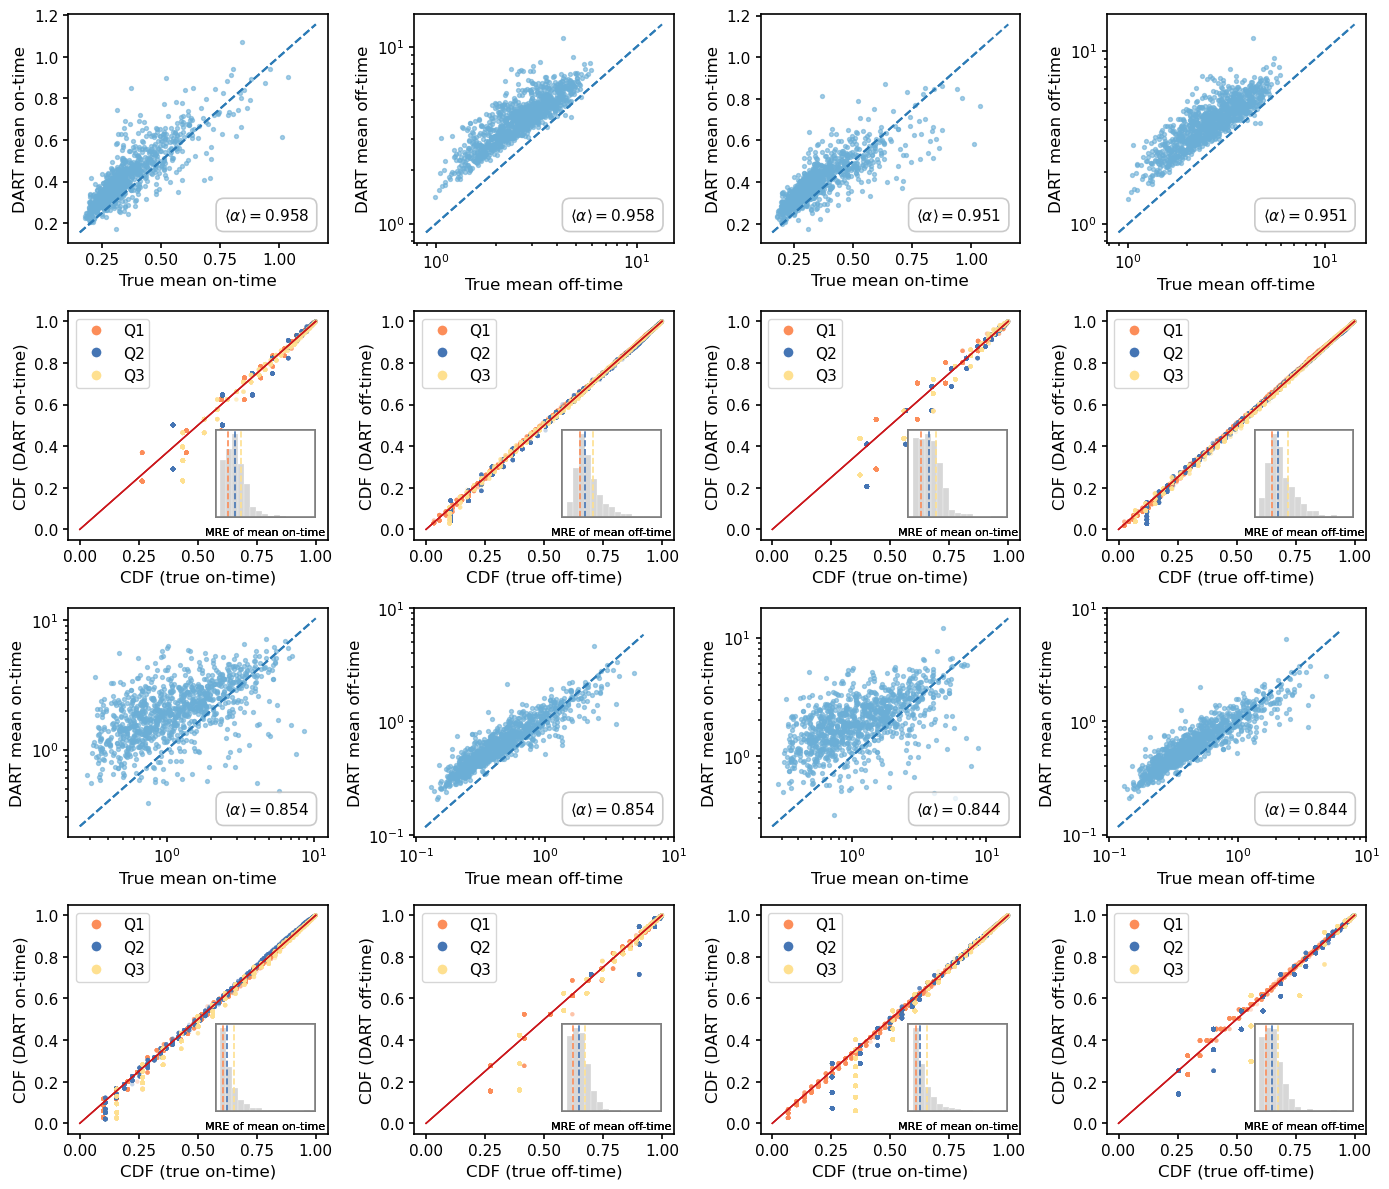

In [8]:
fig, axs = plt.subplots(4, 4, figsize=(14, 12))  # 2 rows, 4 columns  gridspec_kw=Dict("hspace"=>0.3, "wspace"=>0.4)

# high burstiness
rn_data = copy(genb_ntest_cv0[1:1000]);
rn_params = [d.p for d in rn_data];
rn_data_true = copy(genb_ntest_cv0[1:1000]);

plot_obst!(axs[1:2, 1:2], rn_metb_dlm2; axis_log_on=false, axis_log_off=true)  # Left plot
plot_obst!(axs[1:2, 3:4], rn_metb_dln2; axis_log_on=false, axis_log_off=true)   # Right plot

# low burstiness
rn_data = copy(gennb0_ntest_cv0[1:1000]);
rn_params = [d.p for d in rn_data];
rn_data_true = copy(gennb0_ntest_cv0[1:1000]);

plot_obst!(axs[3:4, 1:2], rn_metnb0_dlm2)  # Left plot
plot_obst!(axs[3:4, 3:4], rn_metnb0_dln2)  # Right plot

targets = (axs[3,2], axs[3,4])   
for ax in targets
    if String(ax[:get_yscale]()) == "log"
        auto_min, auto_max = ax[:get_ylim]()
        new_min = auto_min
        new_max = max(auto_max, 10.0^1)   
        ax[:set_ylim]([new_min, new_max])

        ax[:get_yaxis]()[:set_major_formatter](
            plt[:FuncFormatter]((v,p)->"\$10^{$(Int(round(log10(v))))}\$")
        )
    end
    
    if String(ax[:get_xscale]()) == "log"
        x0, x1 = ax[:get_xlim]()
        ax[:set_xlim]([x0, max(x1, 10.0^1)])
    end
end

plt.tight_layout();

fig.savefig("figs/DLbnb0_m2n2_acc.pdf", bbox_inches="tight", dpi=800);

#### Fig S5 (5% noise level, intermediate burstiness)

In [ ]:
data_dir = "../synthetic_data/real_cv0_data_res";
load_rn_met(path::AbstractString) = (@load path rn_met_dl; copy(rn_met_dl));

@load joinpath(data_dir, "gennb1_ntest_cv0.jld2") gennb1_ntest_cv0

In [28]:
# load and copy
rn_metnb1_dln2 = load_rn_met(joinpath(data_dir, "ngen_dlnb1_compare_seed_1.jld2"))
rn_metnb1_dlm2 = load_rn_met(joinpath(data_dir, "mgen_dlnb1_compare_seed_1.jld2"));

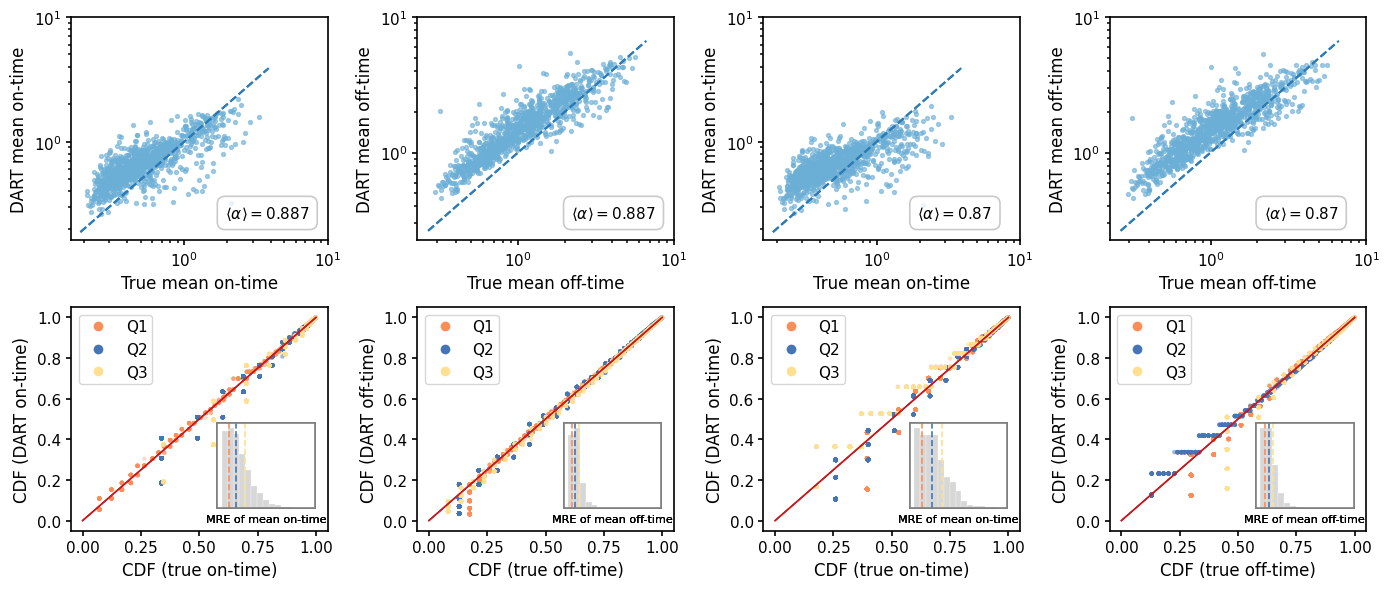

In [50]:
fig, axs = plt.subplots(2, 4, figsize=(14, 6))  # 2 rows, 4 columns  gridspec_kw=Dict("hspace"=>0.3, "wspace"=>0.4)

rn_data = copy(gennb1_ntest_cv0[1:1000]);
rn_params = [d.p for d in rn_data];
rn_data_true = copy(gennb1_ntest_cv0[1:1000]);

plot_obst!(axs[:, 1:2], rn_metnb1_dlm2)  # Left plot
plot_obst!(axs[:, 3:4], rn_metnb1_dln2)  # Right plot

targets = (axs[1,1], axs[1,2], axs[1,3], axs[1,4])   
for ax in targets
    if String(ax[:get_yscale]()) == "log"
        auto_min, auto_max = ax[:get_ylim]()
        new_min = auto_min
        new_max = max(auto_max, 10.0^1)   
        ax[:set_ylim]([new_min, new_max])

        # 格式化为 10^x
        ax[:get_yaxis]()[:set_major_formatter](
            plt[:FuncFormatter]((v,p)->"\$10^{$(Int(round(log10(v))))}\$")
        )
    end
    
    
    if String(ax[:get_xscale]()) == "log"
        x0, x1 = ax[:get_xlim]()
        ax[:set_xlim]([x0, max(x1, 10.0^1)])
    end
end

plt.tight_layout();

fig.savefig("figs/DLnb1_m2n2_acc2.pdf", dpi = 800); #bbox_inches="tight",